# MWE 52 - Synthetic 3D matrix with a centered-vug fraction sweep

This experiment generates one deterministic \(300^3\) porous background and
reuses it for seven nested centered-vug cases. The matrix target porosity is
\(\phi_m=0.25\), every voxel is \(10\,\mu\mathrm{m}\) wide, and the requested
vug fractions are

\[
f_v \in \{0,\ 0.01,\ 0.05,\ 0.10,\ 0.20,\ 0.40,\ 0.60\}.
\]

The phase convention is `True/1 = void` and `False/0 = solid`. Each case is
exported through `voids.io` as:

- a C-order `uint8` RAW file plus its JSON metadata sidecar;
- a NetCDF file with the binary volume and embedded physical/provenance metadata.

The matrix-only case is the unmodified first case. All later cases use the
same background, so changes in total porosity are caused only by the vug.

In [1]:
from __future__ import annotations

import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.generators import (
    generate_spanning_blobs_matrix,
    insert_centered_superellipsoidal_vug,
)
from voids.io import VolumeData, load_volume_data, save_volume_bundle
from voids.paths import notebooks_path

plt.ioff()

## Reproducible configuration

A sphere contained in a cube cannot exceed \(\pi/6\approx0.524\) of the cube
volume. To include the requested \(f_v=0.60\) case without clipping or changing
shape family, the vug is a centered superellipsoid,

\[
\left|\frac{x}{a}\right|^p+
\left|\frac{y}{a}\right|^p+
\left|\frac{z}{a}\right|^p \le 1,
\qquad p=2.5.
\]

This is only slightly more rounded-cube-like than a sphere (\(p=2\)). With a
one-voxel nominal boundary margin, its maximum support is about 0.615 of this
grid, so the 0.60 case expands almost to the image boundary while remaining
enclosed. `voids` selects the outer score shell deterministically so the mask
contains exactly the requested number of voxels.

In [2]:
shape = (300, 300, 300)
voxel_size_um = 10.0
matrix_porosity_target = 0.25
vug_volume_fractions = (0.0, 0.01, 0.05, 0.10, 0.20, 0.40, 0.60)

matrix_blobiness = 2.0
seed_start = 1200
max_seed_tries = 8
spanning_axis = 0

vug_exponent = 2.5
vug_margin_vox = 1

output_dir = (
    notebooks_path()
    / "outputs"
    / "52_mwe_synthetic_3d_matrix_centered_vug_volume_fraction"
)
output_dir.mkdir(parents=True, exist_ok=True)
project_root = notebooks_path().parent
output_dir_relative = output_dir.relative_to(project_root)

configuration = {
    "shape": shape,
    "voxel_size_um": voxel_size_um,
    "physical_size_mm": tuple(size * voxel_size_um / 1000.0 for size in shape),
    "matrix_porosity_target": matrix_porosity_target,
    "vug_volume_fractions": vug_volume_fractions,
    "matrix_blobiness": matrix_blobiness,
    "seed_start": seed_start,
    "max_seed_tries": max_seed_tries,
    "spanning_axis": spanning_axis,
    "vug_geometry": "centered_superellipsoid",
    "vug_exponent": vug_exponent,
    "vug_margin_vox": vug_margin_vox,
    "output_dir": str(output_dir_relative),
}
display(configuration)

{'shape': (300, 300, 300),
 'voxel_size_um': 10.0,
 'physical_size_mm': (3.0, 3.0, 3.0),
 'matrix_porosity_target': 0.25,
 'vug_volume_fractions': (0.0, 0.01, 0.05, 0.1, 0.2, 0.4, 0.6),
 'matrix_blobiness': 2.0,
 'seed_start': 1200,
 'max_seed_tries': 8,
 'spanning_axis': 0,
 'vug_geometry': 'centered_superellipsoid',
 'vug_exponent': 2.5,
 'vug_margin_vox': 1,
 'output_dir': 'notebooks/outputs/52_mwe_synthetic_3d_matrix_centered_vug_volume_fraction'}

## Generate the common porous matrix

`generate_spanning_blobs_matrix` uses PoreSpy through the packaged `voids`
generator and accepts the first deterministic realization that spans the
selected axis. The achieved porosity is checked to one voxel of the requested
count. This is a synthetic correlated random field, not a calibrated rock
microstructure.

In [3]:
matrix_void, seed_used = generate_spanning_blobs_matrix(
    shape=shape,
    porosity=matrix_porosity_target,
    blobiness=matrix_blobiness,
    axis_index=spanning_axis,
    seed_start=seed_start,
    max_tries=max_seed_tries,
)

matrix_porosity_achieved = float(matrix_void.mean())
one_voxel_fraction = 1.0 / matrix_void.size
assert abs(matrix_porosity_achieved - matrix_porosity_target) <= one_voxel_fraction

matrix_summary = {
    "seed_used": seed_used,
    "shape": matrix_void.shape,
    "dtype": str(matrix_void.dtype),
    "void_convention": "True/1 = void",
    "matrix_porosity_target": matrix_porosity_target,
    "matrix_porosity_achieved": matrix_porosity_achieved,
    "void_voxels": int(np.count_nonzero(matrix_void)),
    "solid_voxels": int(matrix_void.size - np.count_nonzero(matrix_void)),
}
display(matrix_summary)

{'seed_used': 1200,
 'shape': (300, 300, 300),
 'dtype': 'bool',
 'void_convention': 'True/1 = void',
 'matrix_porosity_target': 0.25,
 'matrix_porosity_achieved': 0.25,
 'void_voxels': 6750000,
 'solid_voxels': 20250000}

## Generate, export, and round-trip every case

The requested vug fraction is the support of the geometric vug mask divided
by the complete \(300^3\) image support. Because some background pore voxels
already lie inside that support, the increase in total porosity is smaller
than \(f_v\). For each case the notebook reports:

- geometric vug fraction;
- matrix porosity outside the vug;
- vug/background overlap;
- newly opened void fraction;
- final total porosity.

The exact identity is

\[
\phi_{\mathrm{total}}
= f_v + (1-f_v)\phi_{\mathrm{matrix,outside}}.
\]

In [4]:
def _fraction_token(value: float) -> str:
    return f"{value:.2f}".replace(".", "p")


def _sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


rows: list[dict[str, object]] = []
central_slices: dict[float, np.ndarray] = {}
mid_x = shape[0] // 2

for requested_fraction in vug_volume_fractions:
    if requested_fraction == 0.0:
        case_void = matrix_void.copy()
        vug_mask = np.zeros(shape, dtype=bool)
        geometry = "none"
    else:
        case_void, vug_mask = insert_centered_superellipsoidal_vug(
            matrix_void,
            volume_fraction=requested_fraction,
            exponent=vug_exponent,
            margin_vox=vug_margin_vox,
        )
        geometry = "centered_superellipsoid"

    vug_voxels = int(np.count_nonzero(vug_mask))
    achieved_vug_fraction = vug_voxels / matrix_void.size
    expected_vug_voxels = int(np.floor(requested_fraction * matrix_void.size + 0.5))
    assert vug_voxels == expected_vug_voxels

    outside_vug = ~vug_mask
    matrix_porosity_outside = float(matrix_void[outside_vug].mean())
    overlap_voxels = int(np.count_nonzero(matrix_void & vug_mask))
    newly_opened_voxels = int(np.count_nonzero(vug_mask & ~matrix_void))
    total_porosity = float(case_void.mean())
    porosity_identity = (
        achieved_vug_fraction + (1.0 - achieved_vug_fraction) * matrix_porosity_outside
    )
    np.testing.assert_allclose(
        total_porosity,
        porosity_identity,
        rtol=0.0,
        atol=2.0 * one_voxel_fraction,
    )

    if vug_voxels:
        occupied = np.nonzero(vug_mask)
        bounds_min = tuple(int(axis.min()) for axis in occupied)
        bounds_max = tuple(int(axis.max()) for axis in occupied)
        boundary_clearance_vox = min(
            *(bounds_min),
            *(shape[axis] - 1 - bounds_max[axis] for axis in range(3)),
        )
    else:
        bounds_min = None
        bounds_max = None
        boundary_clearance_vox = None

    token = _fraction_token(requested_fraction)
    stem = f"matrix_phi0p25_centered_vug_fv{token}_300x300x300_10um"
    metadata = {
        "case_name": stem,
        "source_kind": "voids_spanning_blobs_with_centered_superellipsoid",
        "phase_convention": "0=solid, 1=void",
        "array_order": "C",
        "axis_order": "axis_0,axis_1,axis_2",
        "matrix_generator": "generate_spanning_blobs_matrix",
        "matrix_seed": int(seed_used),
        "matrix_blobiness": matrix_blobiness,
        "matrix_spanning_axis": spanning_axis,
        "matrix_porosity_target": matrix_porosity_target,
        "matrix_porosity_achieved": matrix_porosity_achieved,
        "vug_geometry": geometry,
        "vug_volume_fraction_target": requested_fraction,
        "vug_volume_fraction_achieved": achieved_vug_fraction,
        "vug_exponent": (None if requested_fraction == 0.0 else vug_exponent),
        "vug_margin_vox": (None if requested_fraction == 0.0 else vug_margin_vox),
        "vug_bounds_min": bounds_min,
        "vug_bounds_max": bounds_max,
        "boundary_clearance_vox": boundary_clearance_vox,
        "matrix_porosity_outside_vug": matrix_porosity_outside,
        "vug_background_overlap_voxels": overlap_voxels,
        "newly_opened_void_voxels": newly_opened_voxels,
        "total_porosity": total_porosity,
    }
    volume = VolumeData(
        values=case_void,
        voxel_size=(voxel_size_um,) * 3,
        units={"length": "um"},
        metadata=metadata,
    )
    paths = save_volume_bundle(
        volume,
        output_dir,
        stem=stem,
        formats=("raw", "nc"),
    )

    raw_roundtrip = load_volume_data(paths["raw"])
    netcdf_roundtrip = load_volume_data(paths["nc"])
    assert raw_roundtrip.values.dtype == bool
    assert netcdf_roundtrip.values.dtype == bool
    assert raw_roundtrip.voxel_size == (voxel_size_um,) * 3
    assert netcdf_roundtrip.voxel_size == (voxel_size_um,) * 3
    assert raw_roundtrip.units == {"length": "um"}
    assert netcdf_roundtrip.units == {"length": "um"}
    assert np.array_equal(raw_roundtrip.values, case_void)
    assert np.array_equal(netcdf_roundtrip.values, case_void)

    central_slices[requested_fraction] = case_void[mid_x].copy()
    rows.append(
        {
            "vug_fraction_target": requested_fraction,
            "vug_fraction_achieved": achieved_vug_fraction,
            "vug_voxels": vug_voxels,
            "boundary_clearance_vox": boundary_clearance_vox,
            "matrix_porosity_outside_vug": matrix_porosity_outside,
            "vug_background_overlap_voxels": overlap_voxels,
            "newly_opened_void_fraction": newly_opened_voxels / matrix_void.size,
            "total_porosity": total_porosity,
            "raw_path": str(paths["raw"].relative_to(project_root)),
            "raw_bytes": paths["raw"].stat().st_size,
            "raw_sha256": _sha256(paths["raw"]),
            "netcdf_path": str(paths["nc"].relative_to(project_root)),
            "netcdf_bytes": paths["nc"].stat().st_size,
            "netcdf_sha256": _sha256(paths["nc"]),
            "roundtrip_verified": True,
        }
    )

    del case_void, vug_mask, raw_roundtrip, netcdf_roundtrip

summary = pd.DataFrame(rows)
summary_path = output_dir / "manifest.csv"
summary.to_csv(summary_path, index=False)
display(summary)

,vug_fraction_target,vug_fraction_achieved,vug_voxels,boundary_clearance_vox,matrix_porosity_outside_vug,vug_background_overlap_voxels,newly_opened_void_fraction,total_porosity,raw_path,raw_bytes,raw_sha256,netcdf_path,netcdf_bytes,netcdf_sha256,roundtrip_verified
0,0.00,0.00,0,NaN,0.250000,0,0.000000,0.250000,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,27000000,c007fd9fa75e2e88da8675946da3fac3a9e3ec7da2cfb4...,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,54001160,faf2cf01d06e7ba6ca7e6cd59e07323688606b11778d74...,True
1,0.01,0.01,270000,112.0,0.249951,68813,0.007451,0.257451,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,27000000,9e4379da4c2c5652b3161285c040c7098ae7f71f581414...,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,54001236,d6864e13c3817aeb8d279658f2e252317883398e13369f...,True
2,0.05,0.05,1350000,86.0,0.250527,323987,0.038000,0.288000,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,27000000,25c9c5846e00ebaabc4f7cf88bf368f88fa597e877cb6d...,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,54001236,938e7f2b52c0f08b8d52ed36f9877fc18a4255abf46bf2...,True
3,0.10,0.10,2700000,69.0,0.250844,654480,0.075760,0.325760,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,27000000,3e03dcd98d6d20df61d2b8175c2de9aca32a3da4427dee...,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,54001220,f350f06205516e577f04ea9096c6662096c5c2d4b30363...,True
4,0.20,0.20,5400000,48.0,0.251087,1326527,0.150869,0.400869,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,27000000,22eddd3e9fe29cdfd238bf901654d61b94061047a693b6...,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,54001232,a55b52aa0c07dbb69ba95a9207783e88a0d7c30bb941ed...,True
5,0.40,0.40,10800000,21.0,0.250874,2685844,0.300524,0.550524,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,27000000,c6ef01e2c1809d3702d204f01dac8f550b6e16a0930455...,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,54001232,78defdc9d71e82c541ec07fb1c61a32f09130d3571e2b9...,True
6,0.60,0.60,16200000,3.0,0.251803,4030526,0.450721,0.700721,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,27000000,8f58e75ac6d1b91216f76b58a894840c58c109e493f769...,notebooks/outputs/52_mwe_synthetic_3d_matrix_c...,54001232,37086db314a45a223ea6fb2033a27fb2948bd717ecde4d...,True


## Central-slice inspection

Every panel uses the same matrix realization. White pixels are void. The
\(f_v=0.60\) superellipsoid approaches the image boundary but retains the
configured matrix margin.

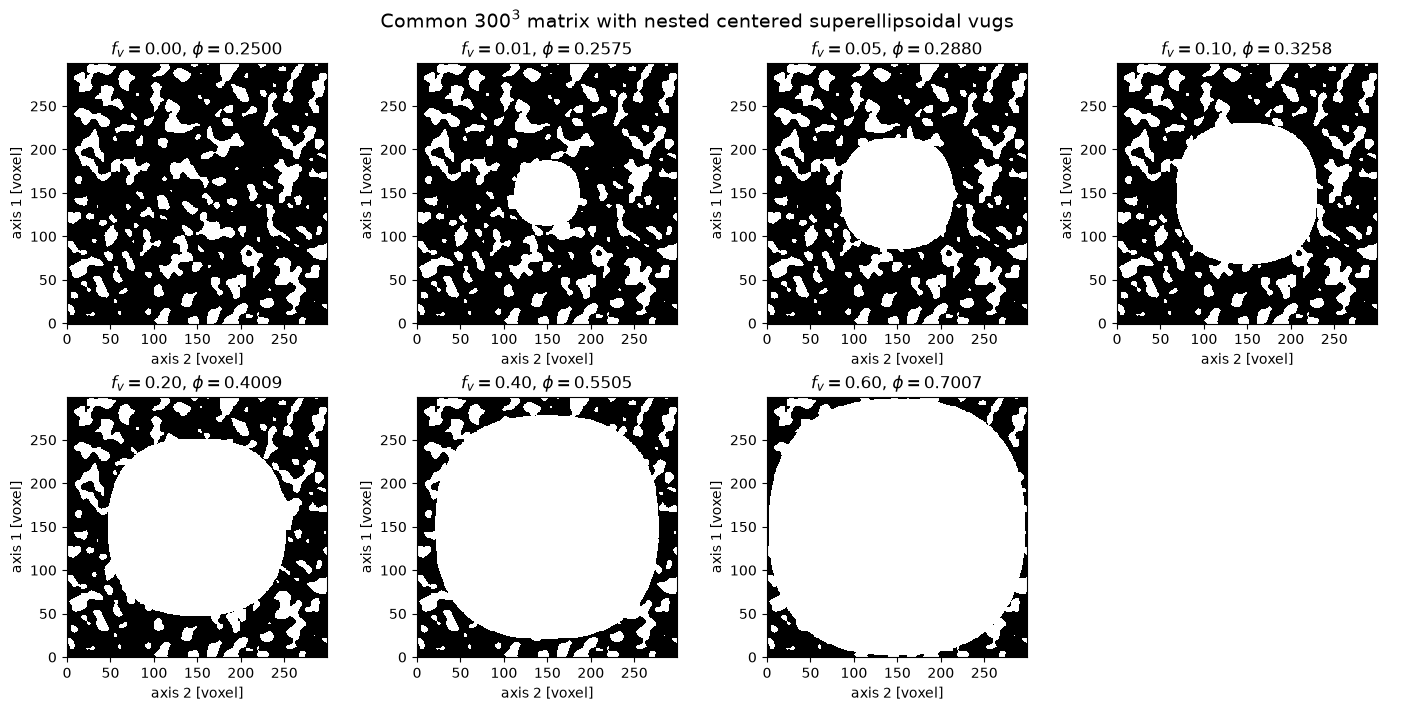

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7), constrained_layout=True)
for axis, requested_fraction in zip(axes.flat, vug_volume_fractions):
    axis.imshow(
        central_slices[requested_fraction],
        cmap="gray",
        origin="lower",
        interpolation="nearest",
        vmin=0,
        vmax=1,
    )
    row = summary.loc[summary["vug_fraction_target"] == requested_fraction].iloc[0]
    axis.set_title(
        f"$f_v={requested_fraction:.2f}$, " f"$\\phi={row['total_porosity']:.4f}$"
    )
    axis.set_xlabel("axis 2 [voxel]")
    axis.set_ylabel("axis 1 [voxel]")
axes.flat[-1].axis("off")
fig.suptitle(
    "Common $300^3$ matrix with nested centered superellipsoidal vugs",
    fontsize=14,
)
display(fig)
plt.close(fig)

## Verification summary

The assertions above establish:

- the common background has \(\phi_m=0.25\) to one-voxel precision;
- every geometric vug mask has the requested support count;
- the porosity decomposition identity holds;
- RAW and NetCDF reload to the exact binary array;
- both formats retain the 10 µm voxel spacing and phase convention.

`manifest.csv` records paths, sizes, SHA-256 digests, achieved fractions, and
total porosities. The generated images are deterministic for the recorded
seed and package versions, but the PoreSpy background is a synthetic model,
not a calibrated geological texture.

In [6]:
verification = {
    "cases": len(summary),
    "all_roundtrips_verified": bool(summary["roundtrip_verified"].all()),
    "maximum_vug_fraction_error": float(
        np.max(
            np.abs(summary["vug_fraction_achieved"] - summary["vug_fraction_target"])
        )
    ),
    "matrix_porosity_achieved": matrix_porosity_achieved,
    "largest_case_boundary_clearance_vox": int(
        summary.loc[
            summary["vug_fraction_target"] == max(vug_volume_fractions),
            "boundary_clearance_vox",
        ].iloc[0]
    ),
    "manifest": str(summary_path.relative_to(project_root)),
    "output_directory": str(output_dir_relative),
}
display(verification)

{'cases': 7,
 'all_roundtrips_verified': True,
 'maximum_vug_fraction_error': 0.0,
 'matrix_porosity_achieved': 0.25,
 'largest_case_boundary_clearance_vox': 3,
 'manifest': 'notebooks/outputs/52_mwe_synthetic_3d_matrix_centered_vug_volume_fraction/manifest.csv',
 'output_directory': 'notebooks/outputs/52_mwe_synthetic_3d_matrix_centered_vug_volume_fraction'}